# Actually Runing the Plots

## Load everything in

In [1]:
from utils_3 import PairwiseData, Population
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k")
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)

/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 30/30 [00:00<00:00, 31.58it/s]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit
from scipy.optimize import linprog

## Set-up utilities

In [6]:
NUM_SAMPLES = 10_000_000
BETA = 1.0
NUM_ROUNDS = 10

In [8]:
def ij_from_pairwise(w_arr, l_arr, n_items):
    ij_wins = np.zeros((n_items, n_items))
    np.add.at(ij_wins, (w_arr, l_arr), 1.0)
    return ij_wins

def _solve_maximal_lottery(margins, tie_tol=1e-12):
    C = margins.shape[0]
    result = linprog(
        c=np.zeros(C),
        A_ub=-margins.T,
        b_ub=np.zeros(C),
        A_eq=np.ones((1, C)),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * C,
        method='highs',
    )
    lottery = np.maximum(result.x if result.success else np.ones(C) / C, 0)
    lottery[lottery < tie_tol] = 0.0
    s = lottery.sum()
    return lottery / s if s > 0 else np.ones(C) / C

def borda_ranking(ij_wins, with_scores=False):
    num = ij_wins.sum(axis=1)
    denom = ij_wins.sum(axis=1) + ij_wins.sum(axis=0)
    scores = num / denom
    if with_scores:
        return np.argsort(-scores), scores
    else:
        return np.argsort(-scores)

def borda_peeling_ranking(ij_wins):
    remaining = list(range(ij_wins.shape[0]))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        ij_remaining = ij_wins[np.ix_(rem, rem)]
        _, scores = borda_ranking(ij_remaining, with_scores=True)
        w = int(np.argmax(scores))
        ranking.append(remaining[w])
        remaining.pop(w)
    return np.array(ranking)

def copeland_ranking(ij_wins, tol=1e-9):
    m = (ij_wins - ij_wins.T) / (ij_wins + ij_wins.T)
    return np.argsort(-((m > tol).sum(axis=1) - (m < -tol).sum(axis=1)))

def copeland_peeling_ranking(ij_wins, tol=1e-9):
    remaining = list(range(ij_wins.shape[0]))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        ij_remaining = ij_wins[np.ix_(rem, rem)]; m = (ij_remaining - ij_remaining.T) / (ij_remaining + ij_remaining.T)
        scores = (m > tol).sum(axis=1) - (m < -tol).sum(axis=1)
        w = int(np.argmax(scores))
        ranking.append(remaining[w]); remaining.pop(w)
    return np.array(ranking)

def ml_argmax_ranking(ij_wins, tol=1e-12):
    remaining = list(range(ij_wins.shape[0]))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        sub = ij_wins[np.ix_(rem, rem)]
        with np.errstate(invalid='ignore', divide='ignore'):
            margins = np.where(sub + sub.T > 0, (sub - sub.T) / (sub + sub.T), 0.0)
        lot = _solve_maximal_lottery(margins, tol)
        w = int(np.argmax(lot))
        ranking.append(remaining[w]); remaining.pop(w)
    return np.array(ranking)

def ml_nonzero_ranking(ij_wins, tol=1e-12):
    remaining = list(range(ij_wins.shape[0]))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        sub = ij_wins[np.ix_(rem, rem)]
        with np.errstate(invalid='ignore', divide='ignore'):
            margins = np.where(sub + sub.T > 0, (sub - sub.T) / (sub + sub.T), 0.0)
        lot = _solve_maximal_lottery(margins, tol)
        order = np.argsort(-lot)
        nonzero = order[lot[order] > tol]
        if len(nonzero) == 0:
            nonzero = np.array([int(np.argmax(lot))])
        selected = [remaining[i] for i in nonzero]
        ranking.extend(selected)
        remaining = [c for c in remaining if c not in set(selected)]
    return np.array(ranking)

In [31]:
def leaderboard_dist_w(ranking, true_ranking, avg_utils, w):
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)

    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]

    # denom_cumsum = np.cumsum(ranking_utils)
    # num_cumsum = np.cumsum(true_ranking_utils)

    # ratio = np.max(num_cumsum / denom_cumsum)
    # k = np.argmax(num_cumsum / denom_cumsum)
    num = true_ranking_utils * w
    denom = ranking_utils * w

    ratio = num.sum() / denom.sum()

    return ratio, None

In [30]:
def ranking_distribution_pruned(candidates, maximal_lottery_fn):
    cache = {}

    def get_lottery(S):
        S = frozenset(S)
        if S not in cache:
            cache[S] = maximal_lottery_fn(list(S))
        return cache[S]

    def recurse(remaining):
        remaining = frozenset(remaining)
        if len(remaining) == 1:
            c = next(iter(remaining))
            return {(c,): 1.0}
        ml = get_lottery(remaining)
        result = {}
        for c, p in ml.items():
            if p == 0:
                continue
            for suffix, q in recurse(remaining - {c}).items():
                result[(c,) + suffix] = p * q
        return result

    return recurse(frozenset(candidates))


def expected_average_utilities(ranking_dist, avg_utilities):
    summed = np.zeros(len(avg_utilities))
    for ranking, p in ranking_dist.items():
        summed += p * avg_utilities[np.asarray(ranking)]
    return summed


def expected_leaderboard_distortion(ranking_dist, true_ranking, avg_utils):
    true_ranking = np.asarray(true_ranking)
    ranking_utils = expected_average_utilities(ranking_dist, avg_utils)
    true_ranking_utils = avg_utils[true_ranking]
    denom_cumsum = np.cumsum(ranking_utils)
    num_cumsum   = np.cumsum(true_ranking_utils)
    return float(np.max(num_cumsum / denom_cumsum))

def expected_leaderboard_distortion_w(ranking_dist, true_ranking, avg_utils, w):
    # ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)

    ranking_utils = expected_average_utilities(ranking_dist=ranking_dist, avg_utilities=avg_utils)
    true_ranking_utils = avg_utils[true_ranking]

    denom = (ranking_utils * w).sum()
    num = (true_ranking_utils * w).sum()

    ratio = num / denom
    return ratio


def make_ml_fn_from_ij_wins(ij_wins):
    def fn(candidates):
        sub = ij_wins[np.ix_(candidates, candidates)]
        with np.errstate(invalid='ignore', divide='ignore'):
            margins = np.where(sub + sub.T > 0, (sub - sub.T) / (sub + sub.T), 0.0)
        lot = _solve_maximal_lottery(margins)
        return {c: float(lot[i]) for i, c in enumerate(candidates)}
    return fn

In [10]:
SMALL_BETAS = np.asarray([0.01, 0.1, 0.5, 1.0, 2.0, ])
BETAS = np.asarray([3.0, 5.0, 10.0, 15.0, 20, 25, 30.0, 35.0, 40.0, 45.0, 50.0])

In [24]:
true_ranking = np.argsort(-population.avg_utilities)

## Plotting many samples

In [13]:
np.concat([SMALL_BETAS, BETAS])

array([1.0e-02, 1.0e-01, 5.0e-01, 1.0e+00, 2.0e+00, 3.0e+00, 5.0e+00,
       1.0e+01, 1.5e+01, 2.0e+01, 2.5e+01, 3.0e+01, 3.5e+01, 4.0e+01,
       4.5e+01, 5.0e+01])

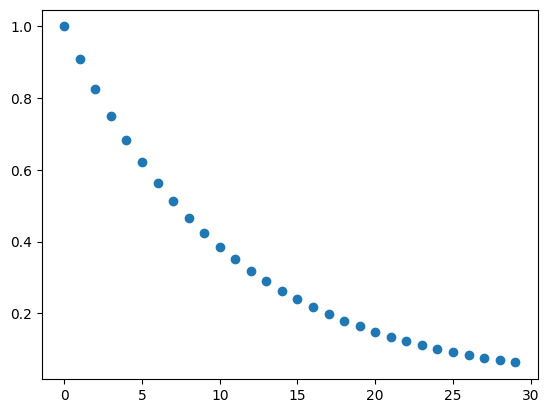

In [15]:
w = 1 / (1.1 ** np.arange(pw.M))
plt.scatter(x=np.arange(len(w)), y=w)

In [17]:
candidates = np.arange(pw.M)

In [20]:
from tqdm import tqdm

In [33]:
def leaderboard_dist(ranking, true_ranking, avg_utils):
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)

    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]

    denom_cumsum = np.cumsum(ranking_utils)
    num_cumsum = np.cumsum(true_ranking_utils)

    ratio = np.max(num_cumsum / denom_cumsum)
    k = np.argmax(num_cumsum / denom_cumsum)
    return ratio, k

In [ ]:
betas = BETAS
# betas = np.concat([SMALL_BETAS, BETAS])

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_argmax', 'ml_nonzero', 'ml_sampling']
betas_distortions = {m: {float(b): [] for b in betas} for m in methods}
supremum_distortions = {m: {float(b): [] for b in betas} for m in methods}

# sample pairs once — only Bernoulli draws vary across rounds
model_As_fixed = np.random.choice(candidates, size=NUM_SAMPLES, p=pw.candidate_distr)
model_Bs_fixed = np.random.choice(candidates, size=NUM_SAMPLES, p=pw.candidate_distr)
u_diff = population.population_utilities[:, model_As_fixed] - population.population_utilities[:, model_Bs_fixed]

for beta in tqdm(betas, desc='beta'):
    p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

    for _ in range(NUM_ROUNDS):
        mask = np.random.rand(NUM_SAMPLES) < p
        w_arr = np.where(mask, model_As_fixed, model_Bs_fixed)
        l_arr = np.where(mask, model_Bs_fixed, model_As_fixed)
        ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

        for m, fn in [
            ('borda',            borda_ranking),
            ('borda_peeling',    borda_peeling_ranking),
            ('copeland',         copeland_ranking),
            ('copeland_peeling', copeland_peeling_ranking),
            ('ml_argmax',        ml_argmax_ranking),
            ('ml_nonzero',       ml_nonzero_ranking),
        ]:
            w_dist, _ = leaderboard_dist_w(fn(ij_wins), true_ranking, population.avg_utilities, w=w)
            dist, _ = leaderboard_dist(fn(ij_wins), true_ranking, population.avg_utilities)
            betas_distortions[m][float(beta)].append(w_dist)
            supremum_distortions[m][float(beta)].append(dist)

        ml_fn = make_ml_fn_from_ij_wins(ij_wins)
        ranking_dist = ranking_distribution_pruned(list(range(pw.M)), ml_fn)
        dist = expected_leaderboard_distortion(ranking_dist, true_ranking, population.avg_utilities)
        w_dist = expected_leaderboard_distortion_w(ranking_dist, true_ranking, population.avg_utilities, w=w)
        betas_distortions['ml_sampling'][float(beta)].append(w_dist)
        supremum_distortions['ml_sampling'][float(beta)].append(dist)

beta:   9%|▉         | 1/11 [00:11<01:52, 11.26s/it]